<a href="https://colab.research.google.com/github/ademiiskak126-ui/Diabetes_Prediction/blob/main/Predictive_Earthquake_Analytics_for_Almaty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Скачиваем данные только по Алматы...
 Данные загружены: 55 событий


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1940-08-30T12:30:42.490Z,44.392,79.764,15.0,5.56,mw,NaN,NaN,NaN,NaN,...,2022-04-26T19:36:40.202Z,"31 km NW of Zharkent, Kazakhstan",earthquake,NaN,25.0,0.63,NaN,reviewed,iscgem,iscgem
1,1940-08-30T15:02:09.280Z,44.642,79.633,15.0,5.84,mw,NaN,NaN,NaN,NaN,...,2022-04-26T19:36:41.261Z,"60 km NNW of Zharkent, Kazakhstan",earthquake,NaN,25.0,0.20,NaN,reviewed,iscgem,iscgem
2,1969-05-01T04:00:06.270Z,44.016,77.987,20.2,5.20,mw,NaN,NaN,NaN,NaN,...,2022-04-26T22:05:35.328Z,"38 km S of Saryozek, Kazakhstan",earthquake,NaN,25.0,0.20,NaN,reviewed,iscgem,iscgem
3,1978-03-23T21:13:15.800Z,44.521,79.353,33.0,4.70,mb,NaN,NaN,NaN,NaN,...,2022-04-27T15:52:05.218Z,"54 km SE of Tekeli, Kazakhstan",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
4,1979-09-25T13:05:53.600Z,45.083,77.006,40.0,5.90,mb,NaN,NaN,NaN,NaN,...,2025-12-19T22:03:45.304Z,"65 km ENE of Bakanas, Kazakhstan",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us


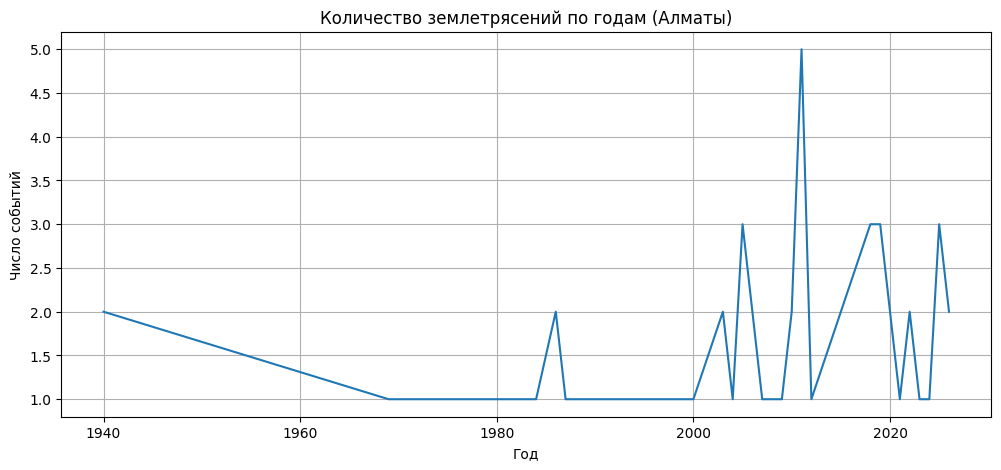

 Потенциально опасных событий: 3


,latitude,longitude,depth,mag,anomaly
4,45.083,77.006,40.0,5.9,-1
20,44.007,75.073,10.0,4.9,-1
22,43.640,77.312,0.0,3.5,-1


 Карта сохранена: almaty_earthquake_anomalies.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 CSV с анализом готов для скачивания


In [1]:
#  Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import folium
from google.colab import files

#  Скачиваем только регион Алматы
# Ограничение по широте и долготе
min_lat, max_lat = 43.5, 46.0
min_lon, max_lon = 75.0, 80.0

url = (
    f"https://earthquake.usgs.gov/fdsnws/event/1/query.csv?"
    f"starttime=1900-01-01&endtime=2026-12-31"
    f"&minmagnitude=2.0&minlatitude={min_lat}&maxlatitude={max_lat}"
    f"&minlongitude={min_lon}&maxlongitude={max_lon}"
    f"&orderby=time-asc"
)

print(" Скачиваем данные только по Алматы...")
df_almaty = pd.read_csv(url)
print(f" Данные загружены: {len(df_almaty)} событий")
display(df_almaty.head())

#  Визуализация количества землетрясений по годам
df_almaty['year'] = pd.to_datetime(df_almaty['time']).dt.year
quake_by_year = df_almaty['year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(quake_by_year.index, quake_by_year.values)
plt.title("Количество землетрясений по годам (Алматы)")
plt.xlabel("Год")
plt.ylabel("Число событий")
plt.grid(True)
plt.show()

#  Детекция аномалий (раннее предупреждение)
data = df_almaty[['latitude', 'longitude', 'depth', 'mag']].dropna()
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
model.fit(data)
data['anomaly'] = model.predict(data)
anomalies = data[data['anomaly'] == -1]
print(f" Потенциально опасных событий: {len(anomalies)}")
display(anomalies.head())

#  Карта с красными (аномалии) и синими точками
map_almaty = folium.Map(location=[43.25, 76.92], zoom_start=8)
for idx, row in data.iterrows():
    color = 'red' if row['anomaly'] == -1 else 'blue'
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5, color=color, fill=True, fill_opacity=0.7
    ).add_to(map_almaty)
map_almaty.save("almaty_earthquake_anomalies.html")
print(" Карта сохранена: almaty_earthquake_anomalies.html")

#  Сохраняем CSV и даём ссылку на скачивание
data.to_csv("earthquakes_almaty_analyzed.csv", index=False)
files.download("earthquakes_almaty_analyzed.csv")
print(" CSV с анализом готов для скачивания")